In [2]:
from src.hybrid_qubo import *
from src.split_cluster import *
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import networkx as nx

def gen_graph(N, D, g, weight_func=lambda: np.random.randint(1, 10), max_attempts=1000):
    """
    Generate a D-regular graph with N nodes and a girth greater than g.
    If the first attempt doesn't meet the girth criteria, keep trying up to max_attempts times.
    Edges are weighted using the specified weight function.

    Parameters:
    D (int): Degree of each node.
    N (int): Number of nodes in the graph.
    g (int): Minimum girth of the graph.
    weight_func (callable, optional): Function to generate edge weights. Defaults to a random integer [1, 10).
    max_attempts (int): Maximum number of attempts to generate a graph meeting the criteria.

    Returns:
    graph: A NetworkX graph object meeting the specified criteria, or None if no such graph can be generated.
    """
    attempt = 0
    while attempt < max_attempts:
        try:
            graph = nx.random_regular_graph(D, N)
            if nx.cycle_basis(graph):
                shortest_cycle = min(len(cycle) for cycle in nx.cycle_basis(graph))
                if shortest_cycle > g:
                    # Assign weights to the edges
                    for (u, v) in graph.edges():
                        graph[u][v]['weight'] = weight_func()
                    return graph
        except nx.NetworkXError as e:
            print(f"Error generating a {D}-regular graph with {N} nodes on attempt {attempt+1}: {e}")
        attempt += 1

    print(f"Failed to generate a graph meeting the criteria after {max_attempts} attempts.")
    return None


In [4]:
import numpy as np
import pickle

def save_data(data_list, filename='qubo_data.pkl'):
    with open(filename, 'wb') as f:
        # Serializing the data list using pickle
        pickle.dump(data_list, f)

def load_data(filename='qubo_data.pkl'):
    with open(filename, 'rb') as f:
        # Deserializing the data from the file
        data_list = pickle.load(f)
    return data_list

## Benchmarking on 3-Regular Graph

In [5]:
import numpy as np
import pickle
from qiskit_optimization.applications import Maxcut
from tqdm import tqdm


data_list = []

for _ in tqdm(range(10)):  # tqdm will display the progress
    G = gen_graph(40, 3, 3)
    qubo = Maxcut(G).to_quadratic_program()

    variables = qubo.variables
    qubo_matrix = qubo.objective.quadratic.to_array()
    linear_terms = qubo.objective.linear.to_array()

    np.fill_diagonal(qubo_matrix, qubo_matrix.diagonal() + linear_terms)
    qubo_matrix *= -1

    res_impact = hybrid_qubo_solve(qubo_matrix, group_method='random')
    res_cluster = hybrid_qubo_solve(qubo_matrix, group_method='pool')

    data_list.append({
        'matrix': qubo_matrix,
        'res_impact': res_impact,
        'res_cluster': res_cluster
    })
    save_data(data_list, filename='100Nodes3Regular_test.pkl')


  0%|          | 0/10 [00:00<?, ?it/s]

new minimum found in QAOA -103.0  lesser than  -96.0
new minimum found in QAOA -79.0  lesser than  -77.0


 10%|█         | 1/10 [00:30<04:33, 30.34s/it]

new minimum found in QAOA -88.0  lesser than  -87.0
new minimum found in QAOA -90.0  lesser than  -84.0


 20%|██        | 2/10 [01:20<05:34, 41.87s/it]

...

 80%|████████  | 8/10 [04:09<00:54, 27.32s/it]

new minimum found in QAOA -112.0  lesser than  -111.0


 90%|█████████ | 9/10 [04:24<00:23, 23.27s/it]

new minimum found in QAOA -104.0  lesser than  -101.0


100%|██████████| 10/10 [04:56<00:00, 29.64s/it]


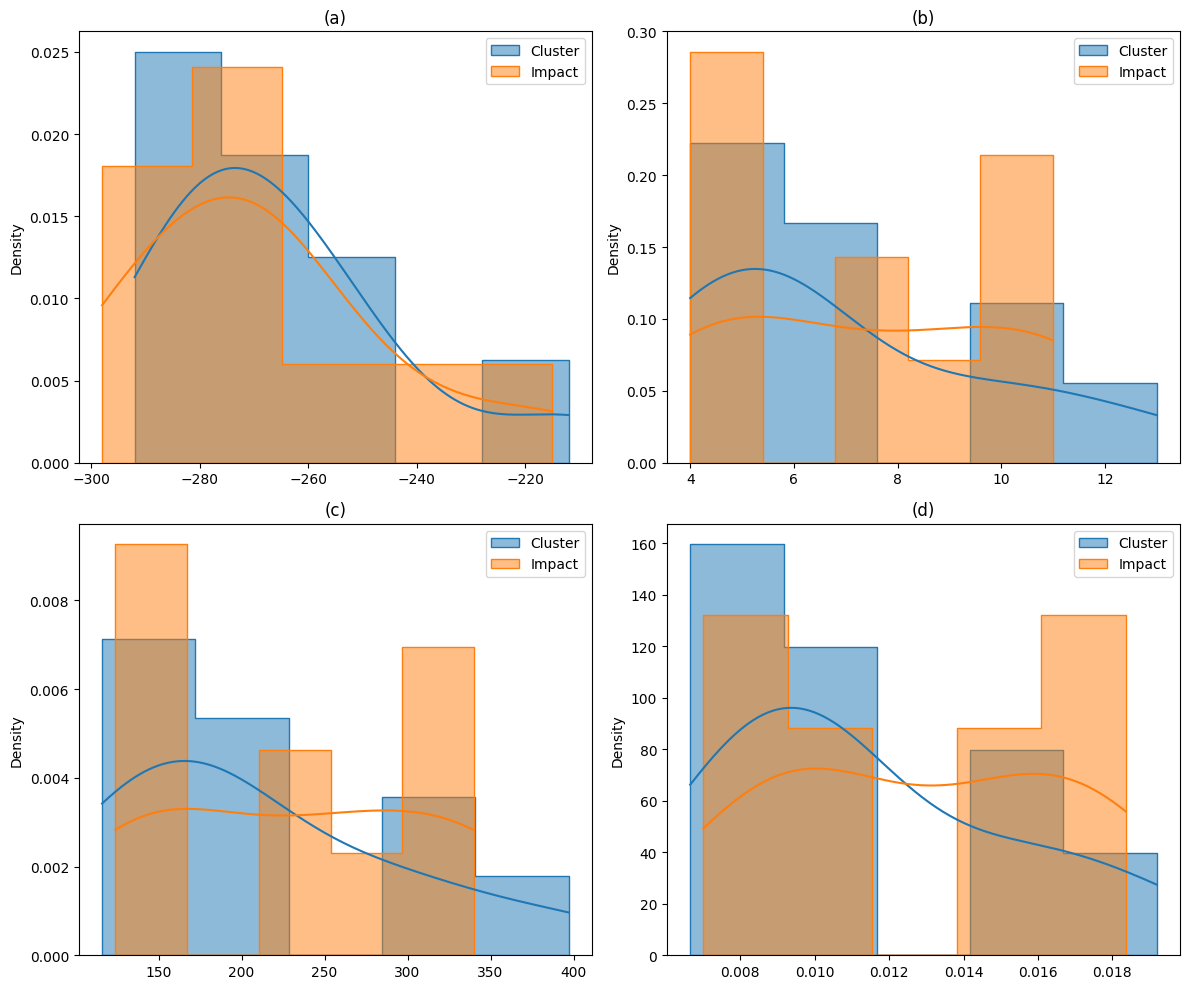

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

data_list = load_data('100Nodes3Regular_test.pkl')

# 初始化数据列表
vals_impact = [entry['res_impact']['val'] for entry in data_list]
vals_cluster = [entry['res_cluster']['val'] for entry in data_list]

quantum_calls_impact = [entry['res_impact']['quantum_calls'] for entry in data_list]
quantum_calls_cluster = [entry['res_cluster']['quantum_calls'] for entry in data_list]

total_iters_impact = [entry['res_impact']['total_iters'] for entry in data_list]
total_iters_cluster = [entry['res_cluster']['total_iters'] for entry in data_list]

classical_runtime_impact = [entry['res_impact']['classical_runtime'] for entry in data_list]
classical_runtime_cluster = [entry['res_cluster']['classical_runtime'] for entry in data_list]

# 创建 2x2 的图表布局
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 最小值分布图
sns.histplot(vals_cluster, kde=True, label='Cluster', element='step', stat='density', alpha=0.5, ax=axes[0, 0])
sns.histplot(vals_impact, kde=True, label='Impact', element='step', stat='density', alpha=0.5, ax=axes[0, 0])
axes[0, 0].legend()
axes[0, 0].set_title('(a) Distribution of Minimum Values')
axes[0, 0].set_title('(a)')

# 量子进程调用数分布图
sns.histplot(quantum_calls_cluster, kde=True, label='Cluster', element='step', stat='density', alpha=0.5, ax=axes[0, 1])
sns.histplot(quantum_calls_impact, kde=True, label='Impact', element='step', stat='density', alpha=0.5, ax=axes[0, 1])
axes[0, 1].legend()
axes[0, 1].set_title('(b) Distribution of Quantum Calls')
axes[0, 1].set_title('(b)')

# 量子优化次数分布图
sns.histplot(total_iters_cluster, kde=True, label='Cluster', element='step', stat='density', alpha=0.5, ax=axes[1, 0])
sns.histplot(total_iters_impact, kde=True, label='Impact', element='step', stat='density', alpha=0.5, ax=axes[1, 0])
axes[1, 0].legend()
axes[1, 0].set_title('(c) Distribution of Total Quantum Iterations')
axes[1, 0].set_title('(c)')

# 经典运行时间分布图
sns.histplot(classical_runtime_cluster, kde=True, label='Cluster', element='step', stat='density', alpha=0.5, ax=axes[1, 1])
sns.histplot(classical_runtime_impact, kde=True, label='Impact', element='step', stat='density', alpha=0.5, ax=axes[1, 1])
axes[1, 1].legend()
axes[1, 1].set_title('(d) Distribution of Classical Runtime')
axes[1, 1].set_title('(d)')

plt.tight_layout()
plt.show()


画一个两种方法目标函数值随轮次的变化

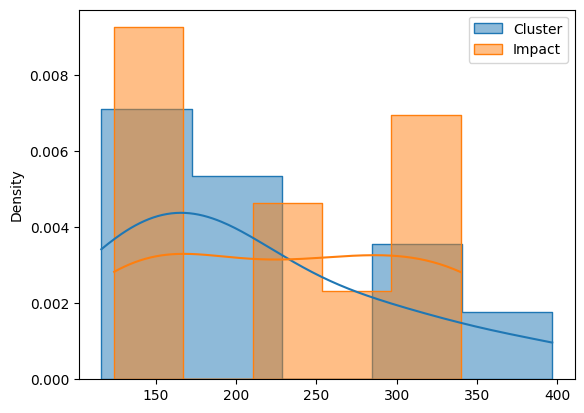

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt


# 提取评估值
vals_impact = [entry['res_impact']['total_iters'] for entry in data_list]
vals_cluster = [entry['res_cluster']['total_iters'] for entry in data_list]

# 绘制直方图
sns.histplot(vals_cluster, kde=True, label='Cluster', element='step', stat='density', alpha=0.5)
sns.histplot(vals_impact, kde=True, label='Impact', element='step', stat='density', alpha=0.5)
plt.legend()
plt.show()

1. 记录量子子过程调用的次数、量子过程优化的次数和经典算法消耗的时间作为时间复杂度的指标
2. 调查d对于表现的影响，对于量子子过程调用次数的影响，说明我们的算法对d的要求更低
3. 训练一个局部最低点好坏的分类器

1. 整理regular-graph对应什么样的具体问题
2. 试一下其他问题的表现
3. 如何体现量子优势：
   1. 理论的proposal：在离子阱计算机上去实现（长程连接，all-connectivity）直接做适合于离子阱的gate
   2. 在自己的系统上运行：hardware-efficient的ansatz
4. 调一下各个方面的参数

# Benchmarking on randomly generated matrices

In [ ]:
import numpy as np
import pickle
from qiskit_optimization.applications import Maxcut
from tqdm import tqdm


data_list = []

for _ in tqdm(range(100)):  # tqdm will display the progress

    qubo = np.random.randint(-10, 11, (100, 100))

    variables = qubo.variables
    qubo_matrix = qubo.objective.quadratic.to_array()
    linear_terms = qubo.objective.linear.to_array()

    np.fill_diagonal(qubo_matrix, qubo_matrix.diagonal() + linear_terms)
    qubo_matrix *= -1

    res_impact = hybrid_qubo_solve(qubo_matrix, group_method='impact')
    res_cluster = hybrid_qubo_solve(qubo_matrix, group_method='cluster')

    data_list.append({
        'matrix': qubo_matrix,
        'res_impact': res_impact,
        'res_cluster': res_cluster
    })

save_data(data_list, filename='random100.pkl')

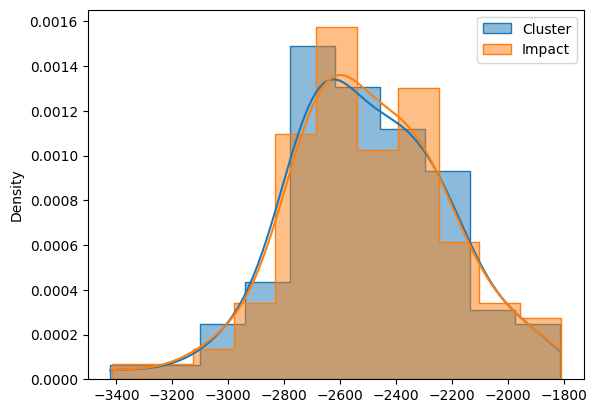

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


# 加载数据
data_list = load_data('random100.pkl')

# 提取评估值
vals_impact = [entry['res_impact']['val'] for entry in data_list]
vals_cluster = [entry['res_cluster']['val'] for entry in data_list]

# 绘制直方图
sns.histplot(vals_cluster, kde=True, label='Cluster', element='step', stat='density', alpha=0.5)
sns.histplot(vals_impact, kde=True, label='Impact', element='step', stat='density', alpha=0.5)
plt.legend()
plt.show()